In [9]:
#Google Stock Price Prediction using RNN - LSTM
#Watch Full Video Here: https://youtu.be/arydWPLDnEc
#What is RNN
#Ref- https://colah.github.io/posts/2015-08-Understanding-LSTMs/
#Download Dataset- https://finance.yahoo.com/quote/GOOG/history/
#Recurrent Neural Networks are the first of its kind State of the Art algorithms that can Memorize/remember previous inputs in memory, 
#When a huge set of Sequential data is given to it. Recurrent Neural Networks are the first of its kind State of the Art algorithms that
#can Memorize/remember previous inputs in memory, When a huge set of Sequential data is given to it.
#Recurrent Neural Networks are the first of its kind State of the Art algorithms that can Memorize/remember previous
#inputs in memory, When a huge set of Sequential data is given to it. Recurrent Neural Networks are the first of its 
#kind State of the Art algorithms that can Memorize/remember previous inputs in memory, When a huge set of Sequential data is given to it.
import numpy as np
from tensorflow.keras.preprocessing import image
# Load image with target size (e.g., 224x224 for models like ResNet)
img_path = r"C:\Users\KIIT\Downloads\download (6).png"
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
# Normalize
img_array = img_array / 255.0
# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)
print("Shape:", img_array.shape)


Shape: (1, 224, 224, 3)


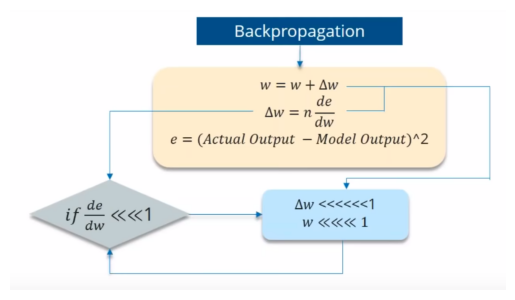

In [11]:
from PIL import Image
import matplotlib.pyplot as plt
img = Image.open(r"C:\Users\KIIT\Downloads\download (4).png")
plt.imshow(img)
plt.axis('off')
plt.show()

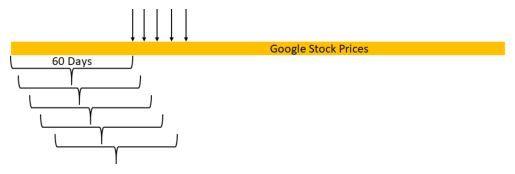

In [12]:
from PIL import Image
import matplotlib.pyplot as plt
img = Image.open(r"C:\Users\KIIT\Downloads\download (5).png")
plt.imshow(img)
plt.axis('off')
plt.show()

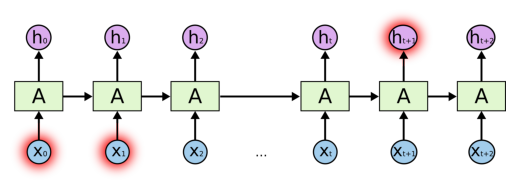

In [14]:
from PIL import Image
import matplotlib.pyplot as plt
img = Image.open(r"C:\Users\KIIT\Downloads\download (3).png")
plt.imshow(img)
plt.axis('off')
plt.show()

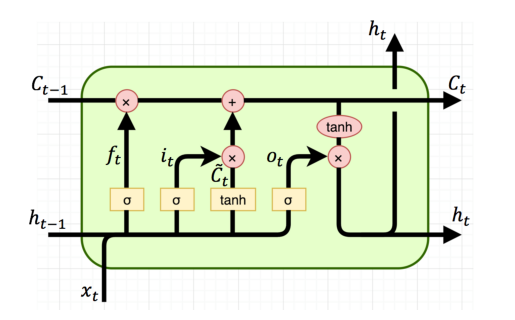

In [15]:
from PIL import Image
import matplotlib.pyplot as plt
img = Image.open(r"C:\Users\KIIT\Downloads\download (8).png")
plt.imshow(img)
plt.axis('off')
plt.show()

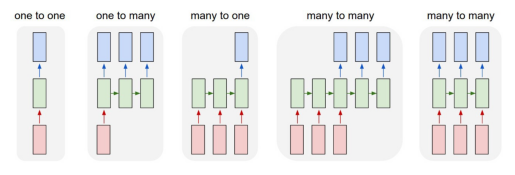

In [17]:
from PIL import Image
import matplotlib.pyplot as plt
img = Image.open(r"C:\Users\KIIT\Downloads\download (2).png")
plt.imshow(img)
plt.axis('off')
plt.show()

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

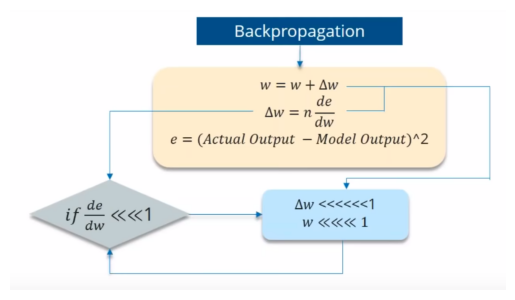

In [16]:
from PIL import Image
import matplotlib.pyplot as plt
img = Image.open(r"C:\Users\KIIT\Downloads\download (4).png")
plt.imshow(img)
plt.axis('off')
plt.show()

In [3]:
import pandas as pd
data = pd.read_csv(r"C:\Users\KIIT\Downloads\GOOG.csv", parse_dates=['Date'])
data.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
3804,2019-09-30,1220.969971,1226.000000,1212.300049,1219.000000,1219.000000,1404100
3805,2019-10-01,1219.000000,1231.229980,1203.579956,1205.099976,1205.099976,1273500
3806,2019-10-02,1196.979980,1196.979980,1171.290039,1176.630005,1176.630005,1615100
3807,2019-10-03,1180.000000,1189.060059,1162.430054,1187.829956,1187.829956,1621200
3808,2019-10-04,1191.890015,1211.439941,1189.170044,1209.000000,1209.000000,1021092


In [4]:
data_training = data[data['Date']<'2019-01-01'].copy()
data_test = data[data['Date']>='2019-01-01'].copy()

In [5]:

data_training = data_training.drop(['Date', 'Adj Close'], axis = 1)

In [6]:
scaler = MinMaxScaler()
data_training = scaler.fit_transform(data_training)
data_training

array([[3.30294890e-04, 9.44785459e-04, 0.00000000e+00, 1.34908021e-04,
        5.43577404e-01],
       [7.42148227e-04, 2.98909923e-03, 1.88269054e-03, 3.39307537e-03,
        2.77885613e-01],
       [4.71386886e-03, 4.78092896e-03, 5.42828241e-03, 3.83867225e-03,
        2.22150736e-01],
       ...,
       [7.92197108e-01, 8.11970141e-01, 7.90196475e-01, 8.15799920e-01,
        2.54672037e-02],
       [8.18777193e-01, 8.21510648e-01, 8.20249255e-01, 8.10219301e-01,
        1.70463908e-02],
       [8.19874096e-01, 8.19172449e-01, 8.12332341e-01, 8.09012935e-01,
        1.79975186e-02]], shape=(3617, 5))

In [7]:
# create RNN with 60 timesteps, i.e. look 60 previous time steps
data_training[0:10]

array([[3.30294890e-04, 9.44785459e-04, 0.00000000e+00, 1.34908021e-04,
        5.43577404e-01],
       [7.42148227e-04, 2.98909923e-03, 1.88269054e-03, 3.39307537e-03,
        2.77885613e-01],
       [4.71386886e-03, 4.78092896e-03, 5.42828241e-03, 3.83867225e-03,
        2.22150736e-01],
       [4.91367646e-03, 4.01532941e-03, 3.15578542e-03, 1.98678849e-03,
        1.85522018e-01],
       [2.35285614e-03, 2.54928676e-03, 3.28434064e-03, 2.44873974e-03,
        1.11762967e-01],
       [2.34877785e-03, 2.52892558e-03, 3.60779701e-03, 3.22955376e-03,
        8.62763771e-02],
       [3.63326671e-03, 2.80177162e-03, 4.03492722e-03, 2.51005881e-03,
        7.55243925e-02],
       [2.48334262e-03, 1.52712947e-03, 2.50886935e-03, 8.17608079e-04,
        6.31682127e-02],
       [1.26817570e-03, 8.02253103e-04, 2.57107531e-03, 9.64778600e-04,
        5.97732318e-02],
       [1.43128522e-03, 5.00900100e-04, 1.53849690e-03, 9.81131336e-05,
        1.11151095e-01]])

In [8]:
X_train = []
y_train = []

In [9]:
for i in range(60, data_training.shape[0]):
    X_train.append(data_training[i-60:i])
    y_train.append(data_training[i, 0])

In [10]:
X_train, y_train = np.array(X_train), np.array(y_train)

In [11]:
X_train.shape

(3557, 60, 5)

In [12]:
#Building LSTM
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

In [14]:
from keras.models import Sequential
from keras.layers import LSTM, Input

model = Sequential()
model.add(Input(shape=(60, 1)))   # ✅ First layer
model.add(LSTM(50))

In [15]:
regressior = Sequential()

regressior.add(LSTM(units = 60, activation = 'relu', return_sequences = True, input_shape = (X_train.shape[1], 5)))
regressior.add(Dropout(0.2))

regressior.add(LSTM(units = 60, activation = 'relu', return_sequences = True))
regressior.add(Dropout(0.2))

regressior.add(LSTM(units = 80, activation = 'relu', return_sequences = True))
regressior.add(Dropout(0.2))

regressior.add(LSTM(units = 120, activation = 'relu'))
regressior.add(Dropout(0.2))

regressior.add(Dense(units = 1))

In [16]:
regressior.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                        │ (None, 60, 60)              │          15,840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 60, 60)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_6 (LSTM)                        │ (None, 60, 60)              │          29,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 60, 60)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 60, 80)              │          45,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 60, 80)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_8 (LSTM)                        │ (None, 120)                 │          96,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 120)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             121 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 186,601 (728.91 KB)

 Trainable params: 186,601 (728.91 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
regressior.compile(optimizer='adam', loss = 'mean_squared_error')

In [18]:
regressior.fit(X_train, y_train, epochs=50, batch_size=32)

Epoch 1/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - loss: 0.0098
Epoch 2/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - loss: 0.0018
Epoch 3/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - loss: 0.0015
Epoch 4/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - loss: 0.0017
Epoch 5/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - loss: 0.0014
Epoch 6/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 82ms/step - loss: 0.0016
Epoch 7/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - loss: 0.0014
Epoch 8/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - loss: 0.0014
Epoch 9/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - loss: 0.0015
Epoch 10/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - loss: 0.0012
Epoch 11/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - loss: 0.0012
Epoch 12/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - loss: 0.0012
Epoch 13/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - loss: 0.0013
Epoch 14/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - loss: 9.9902e-04
Epoch 15/50
112/112 ━━━━━━━━━━━━━━━━━━

In [19]:
#Prepare test dataset
data_test.head()

,Date,Open,High,Low,Close,Adj Close,Volume
3617,2019-01-02,1016.570007,1052.319946,1015.710022,1045.849976,1045.849976,1532600
3618,2019-01-03,1041.000000,1056.979980,1014.070007,1016.059998,1016.059998,1841100
3619,2019-01-04,1032.589966,1070.839966,1027.417969,1070.709961,1070.709961,2093900
3620,2019-01-07,1071.500000,1074.000000,1054.760010,1068.390015,1068.390015,1981900
3621,2019-01-08,1076.109985,1084.560059,1060.530029,1076.280029,1076.280029,1764900


In [21]:
import pandas as pd

data_training = pd.DataFrame(data_training)
data_training.tail(60)

,0,1,2,3,4
3557,0.938056,0.937558,0.922209,0.917818,0.026675
3558,0.915274,0.917929,0.913505,0.908922,0.014254
3559,0.901039,0.913433,0.898723,0.902044,0.023318
3560,0.897797,0.902273,0.907221,0.893715,0.015761
3561,0.885461,0.884141,0.860234,0.846444,0.032324
3562,0.837867,0.863073,0.849528,0.844885,0.035635
3563,0.866567,0.870104,0.864623,0.870128,0.025364
3564,0.867312,0.868834,0.866785,0.855496,0.016533
3565,0.863776,0.877642,0.878024,0.879320,0.023271
3566,0.881679,0.881541,0.877766,0.874732,0.017681


In [22]:
past_60_days = data_training.tail(60)

In [24]:
import pandas as pd

df = pd.concat([past_60_days, data_test], ignore_index=True)
df = df.drop(['Date', 'Adj Close'], axis=1)
df.head()

,0,1,2,3,4,Open,High,Low,Close,Volume
0,0.938056,0.937558,0.922209,0.917818,0.026675,NaN,NaN,NaN,NaN,NaN
1,0.915274,0.917929,0.913505,0.908922,0.014254,NaN,NaN,NaN,NaN,NaN
2,0.901039,0.913433,0.898723,0.902044,0.023318,NaN,NaN,NaN,NaN,NaN
3,0.897797,0.902273,0.907221,0.893715,0.015761,NaN,NaN,NaN,NaN,NaN
4,0.885461,0.884141,0.860234,0.846444,0.032324,NaN,NaN,NaN,NaN,NaN


In [26]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Load dataset
data = pd.read_csv(r"C:\Users\KIIT\Downloads\GOOG.csv", parse_dates=['Date'])

# Sort (important for time series)
data = data.sort_values('Date')

# Split data (70% training)
data_training = data[data['Date'] < '2020-01-01']
data_test = data[data['Date'] >= '2020-01-01']

# Drop unnecessary columns
data_training = data_training.drop(['Date', 'Adj Close'], axis=1)
data_test = data_test.drop(['Date', 'Adj Close'], axis=1)

# Scaling
scaler = MinMaxScaler(feature_range=(0, 1))
data_training_array = scaler.fit_transform(data_training)

# Take last 60 days of training
past_60_days = data_training.tail(60)

# Combine past 60 days + test data
df = pd.concat([past_60_days, data_test], ignore_index=True)

# Drop columns again if needed (safety)
# df = df.drop(['Date', 'Adj Close'], axis=1)  # already dropped above

# Ensure column names are same type (IMPORTANT FIX)
df.columns = df.columns.astype(str)

# Transform using same scaler
inputs = scaler.transform(df)

print(inputs)

[[0.89383386 0.88540998 0.89535033 0.88472746 0.01037275]
 [0.8961775  0.88821961 0.89585915 0.88912244 0.01085497]
 [0.89547524 0.8944848  0.90045497 0.89174006 0.01491393]
 [0.89953371 0.89430721 0.90108691 0.88589889 0.01408033]
 [0.89199651 0.88562394 0.89038515 0.88588272 0.01555003]
 [0.89726354 0.88847802 0.88783283 0.87277036 0.01986221]
 [0.88522687 0.87887838 0.88341754 0.87920937 0.01567362]
 [0.89384204 0.88505478 0.88962197 0.88578577 0.01315585]
 [0.8839612  0.88271339 0.88567442 0.87899941 0.01916674]
 [0.88879541 0.8808564  0.88069291 0.87440235 0.02667883]
 [0.95920271 0.98084921 0.96528909 0.96997005 0.05813269]
 [0.97309308 0.96617119 0.96876057 0.96108304 0.02684725]
 [0.96032145 0.95607907 0.96471465 0.94955415 0.01751287]
 [0.95835341 0.95537666 0.95196448 0.94271926 0.02081092]
 [0.95102854 0.95546546 0.95028694 0.93652256 0.02048378]
 [0.9401759  0.93349696 0.93651582 0.92438773 0.01983677]
 [0.91510633 0.90793561 0.89646645 0.89072209 0.03137631]
 [0.90961063 0

In [27]:
X_test = []
y_test = []

for i in range(60, inputs.shape[0]):
    X_test.append(inputs[i-60:i])
    y_test.append(inputs[i, 0])


In [28]:
X_test, y_test = np.array(X_test), np.array(y_test)
X_test.shape, y_test.shape

((0,), (0,))

In [29]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input

model = Sequential()

# Input layer (FIXED warning)
model.add(Input(shape=(60, 5)))

# LSTM layers
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=60, return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(units=80, return_sequences=True))
model.add(Dropout(0.4))

model.add(LSTM(units=120))
model.add(Dropout(0.5))

# Output layer
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

In [30]:
X_test, y_test = np.array(X_test), np.array(y_test)
X_test.shape, y_test.shape

((0,), (0,))

Dataset loaded: 3809 rows
Date range: 2004-08-19 to 2019-10-04
Train size: 3047 days
Test size : 762 days
X_train shape: (2987, 60, 5)
X_test shape : (762, 60, 5)


C:\Users\KIIT\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 50)              │          11,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,451 (122.86 KB)

 Trainable params: 31,451 (122.86 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.0060 - val_loss: 0.0046
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0016 - val_loss: 0.0012
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0015 - val_loss: 9.0006e-04
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0011 - val_loss: 0.0012
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0012 - val_loss: 0.0010
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0012 - val_loss: 0.0021
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0011 - val_loss: 9.7947e-04
Epoch 9/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0010 - val_loss: 7.0870e-04
Epoch 10/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0010 - val_loss: 0.0015
Epoch 11/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0010 - val_loss: 8.2347e-04
Epoch 12/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/

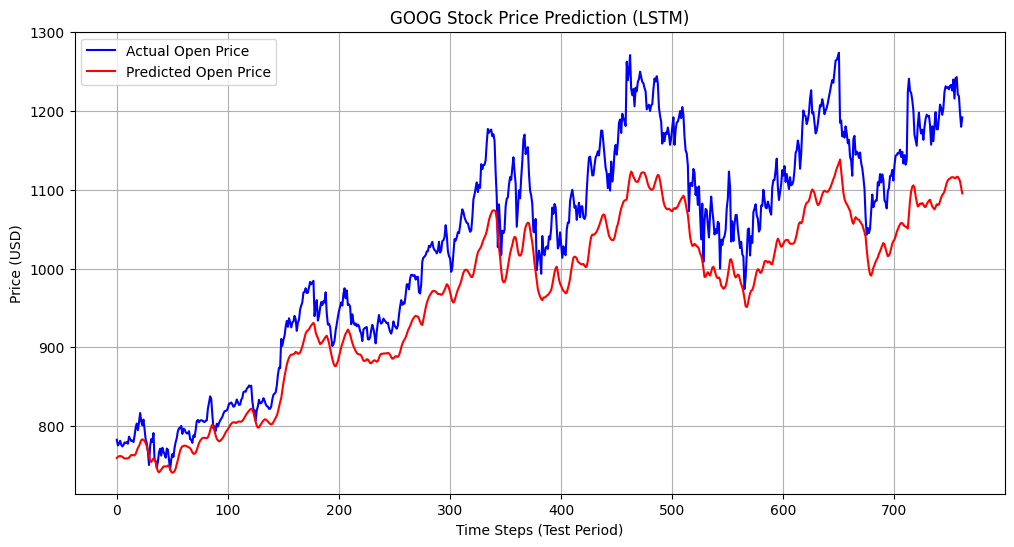

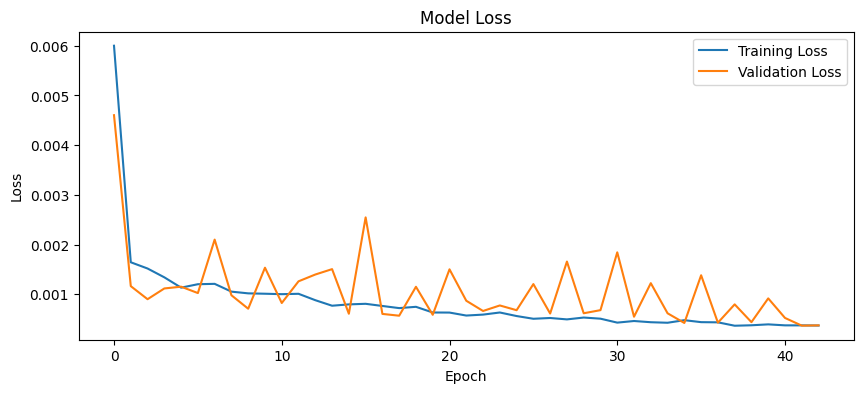

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping

# =========================
# 1. Load Data
# =========================
data = pd.read_csv(r"C:\Users\KIIT\Downloads\GOOG.csv", parse_dates=['Date'])
data = data.sort_values('Date').reset_index(drop=True)

print(f"Dataset loaded: {len(data)} rows")
print(f"Date range: {data['Date'].min().date()} to {data['Date'].max().date()}")

# =========================
# 2. Use Required Columns
# =========================
data = data[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]

# =========================
# 3. Train-Test Split (Better Approach - 80/20)
# =========================
train_size = int(len(data) * 0.80)
train_data = data.iloc[:train_size].copy()
test_data = data.iloc[train_size:].copy()

print(f"Train size: {len(train_data)} days")
print(f"Test size : {len(test_data)} days")

# Drop Date column for scaling
train_df = train_data.drop(['Date'], axis=1)
test_df = test_data.drop(['Date'], axis=1)

# =========================
# 4. Scaling
# =========================
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_df)

# =========================
# 5. Create Training Sequences
# =========================
window_size = 60

X_train, y_train = [], []
for i in range(window_size, len(train_scaled)):
    X_train.append(train_scaled[i - window_size:i])
    y_train.append(train_scaled[i, 0])        # Predicting 'Open' price

X_train = np.array(X_train)
y_train = np.array(y_train)

print(f"X_train shape: {X_train.shape}")

# =========================
# 6. Prepare Test Data (Fixed & Robust)
# =========================
last_window = train_df.tail(window_size).copy()
final_df = pd.concat([last_window, test_df], ignore_index=True)
final_scaled = scaler.transform(final_df)

X_test, y_test = [], []
for i in range(window_size, len(final_scaled)):
    X_test.append(final_scaled[i - window_size:i])
    y_test.append(final_scaled[i, 0])

X_test = np.array(X_test)
y_test = np.array(y_test)

print(f"X_test shape : {X_test.shape}")

# Safety Check
if X_test.shape[0] == 0:
    raise ValueError(f"Not enough test data! Test set has only {len(test_data)} days. "
                     f"Reduce window_size (currently {window_size}) or use more data.")

# =========================
# 7. Build Model
# =========================
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# =========================
# 8. Train Model with Early Stopping
# =========================
early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# =========================
# 9. Prediction
# =========================
y_pred_scaled = model.predict(X_test)

# =========================
# 10. Inverse Scaling (Correct Method)
# =========================
# Create dummy arrays to match original 5 features
y_pred = np.concatenate((y_pred_scaled, np.zeros((y_pred_scaled.shape[0], 4))), axis=1)
y_test_actual = np.concatenate((y_test.reshape(-1, 1), np.zeros((y_test.shape[0], 4))), axis=1)

y_pred = scaler.inverse_transform(y_pred)[:, 0]
y_test_actual = scaler.inverse_transform(y_test_actual)[:, 0]

# =========================
# 11. Plot Results
# =========================
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label='Actual Open Price', color='blue')
plt.plot(y_pred, label='Predicted Open Price', color='red')
plt.title('GOOG Stock Price Prediction (LSTM)')
plt.xlabel('Time Steps (Test Period)')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

# Optional: Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Dataset loaded: 3809 rows
Date range: 2004-08-19 to 2019-10-04
Train days: 3047
Test days : 762
X_train shape: (2987, 60, 5)
X_test shape : (762, 60, 5)


C:\Users\KIIT\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 60, 50)              │          11,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,451 (122.86 KB)

 Trainable params: 31,451 (122.86 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - loss: 0.0057 - val_loss: 0.0017
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0019 - val_loss: 0.0028
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0017 - val_loss: 0.0014
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0014 - val_loss: 0.0020
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0012 - val_loss: 9.6598e-04
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0011 - val_loss: 7.6190e-04
Epoch 9/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0011 - val_loss: 9.2264e-04
Epoch 10/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0010 - val_loss: 0.0021
Epoch 11/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0010 - val_loss: 8.2335e-04
Epoch 12/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/

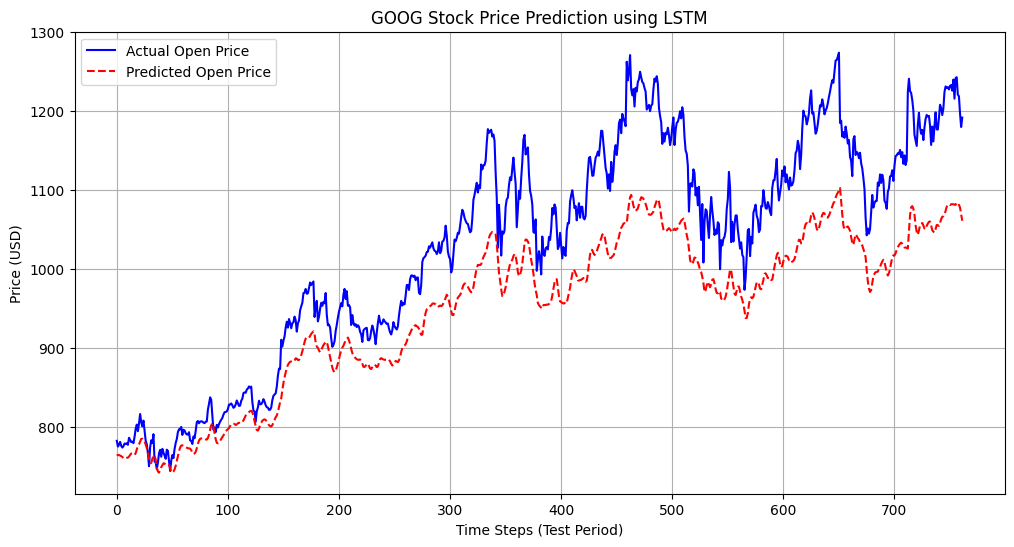

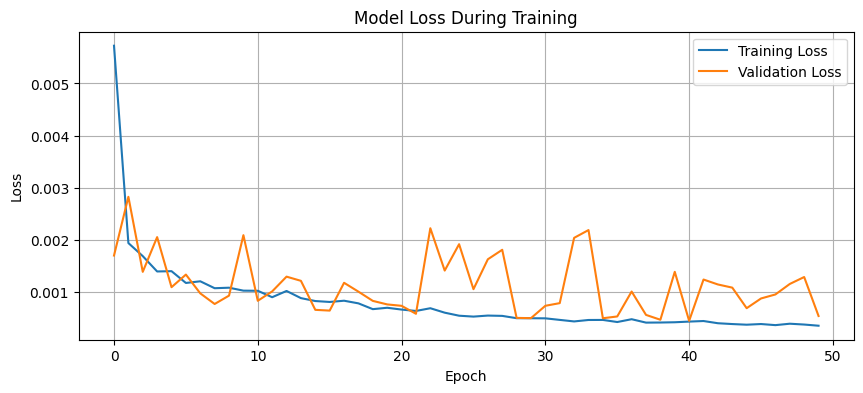

Prediction completed successfully!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping

# =========================
# 1. Load Data
# =========================
data = pd.read_csv(r"C:\Users\KIIT\Downloads\GOOG.csv", parse_dates=['Date'])
data = data.sort_values('Date').reset_index(drop=True)

print(f"Dataset loaded: {len(data)} rows")
print(f"Date range: {data['Date'].min().date()} to {data['Date'].max().date()}")

# =========================
# 2. Select Required Columns
# =========================
data = data[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]

# =========================
# 3. Train-Test Split (80% Train, 20% Test)
# =========================
train_size = int(len(data) * 0.80)
train_data = data.iloc[:train_size].copy()
test_data = data.iloc[train_size:].copy()

print(f"Train days: {len(train_data)}")
print(f"Test days : {len(test_data)}")

train_df = train_data.drop(['Date'], axis=1)
test_df  = test_data.drop(['Date'], axis=1)

# =========================
# 4. Feature Scaling
# =========================
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_df)

# =========================
# 5. Create Training Sequences
# =========================
window_size = 60

X_train, y_train = [], []
for i in range(window_size, len(train_scaled)):
    X_train.append(train_scaled[i-window_size:i])
    y_train.append(train_scaled[i, 0])   # Predicting 'Open' price

X_train = np.array(X_train)
y_train = np.array(y_train)

print(f"X_train shape: {X_train.shape}")

# =========================
# 6. Prepare Test Sequences
# =========================
last_window = train_df.tail(window_size).copy()
final_df = pd.concat([last_window, test_df], ignore_index=True)
final_scaled = scaler.transform(final_df)

X_test, y_test = [], []
for i in range(window_size, len(final_scaled)):
    X_test.append(final_scaled[i-window_size:i])
    y_test.append(final_scaled[i, 0])

X_test = np.array(X_test)
y_test = np.array(y_test)

print(f"X_test shape : {X_test.shape}")

# Safety Check
if len(X_test) == 0:
    raise ValueError(f"Not enough test data! Only {len(test_data)} test days available. "
                     f"Reduce window_size (currently {window_size})")

# =========================
# 7. Build LSTM Model
# =========================
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# =========================
# 8. Train the Model
# =========================
early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# =========================
# 9. Make Predictions
# =========================
y_pred_scaled = model.predict(X_test)

# =========================
# 10. Inverse Transform (Correct Way)
# =========================
# We predicted only the first column (Open), so we add dummy columns for inverse scaling
dummy = np.zeros((y_pred_scaled.shape[0], 4))

y_pred = np.concatenate((y_pred_scaled, dummy), axis=1)
y_actual = np.concatenate((y_test.reshape(-1, 1), dummy), axis=1)

y_pred = scaler.inverse_transform(y_pred)[:, 0]
y_actual = scaler.inverse_transform(y_actual)[:, 0]

# =========================
# 11. Plot the Results
# =========================
plt.figure(figsize=(12, 6))
plt.plot(y_actual, label='Actual Open Price', color='blue')
plt.plot(y_pred, label='Predicted Open Price', color='red', linestyle='--')
plt.title('GOOG Stock Price Prediction using LSTM')
plt.xlabel('Time Steps (Test Period)')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

# Plot Training Loss
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss')
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

print("Prediction completed successfully!")

In [5]:
scale = 1/8.18605127e-04
scale

1221.5901990069017

In [6]:
y_pred = y_pred*scale
y_test = y_test*scale
scale = 1/8.18605127e-04
scale

1221.5901990069017

In [7]:
y_pred = y_pred*scale
y_test = y_test*scale

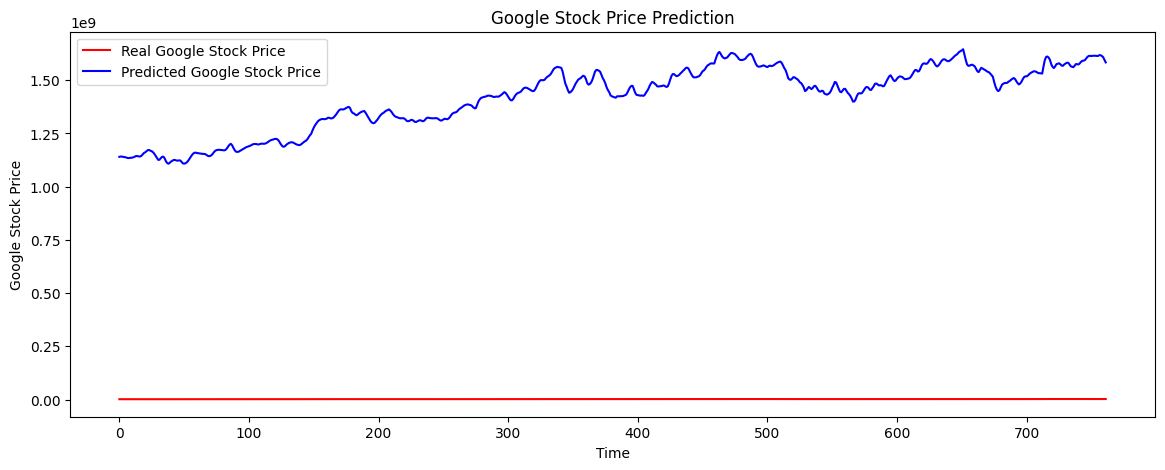

In [8]:
#Visualization
# Visualising the results
plt.figure(figsize=(14,5))
plt.plot(y_test, color = 'red', label = 'Real Google Stock Price')
plt.plot(y_pred, color = 'blue', label = 'Predicted Google Stock Price')
plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Google Stock Price')
plt.legend()
plt.show()